In [98]:
import numpy as np
import matplotlib.pyplot as plt
import random
from numba import njit
from time import time
from numpy import math
from tqdm import tqdm
import warnings

C:\Users\Hadis\AppData\Local\Temp\ipykernel_14480\3492318746.py:6: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  from numpy import math


In [99]:
t1 = time()
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [100]:
ensemble_num = 1
n = 50             # num of nodes
step_mc = 6*(N**2)   # num of monte carlo steps

In [101]:
#network

def Network_maker1(N): # negative and positive link
    negative_network = -np.ones((N, N))
    np.fill_diagonal(negative_network, 0)

    positive_network = np.ones((N, N))
    np.fill_diagonal(positive_network, 0)
    
    return negative_network, positive_network

In [102]:
def Network_maker2(N): # random link network
    random_network= np.random.choice([-1, 1], size=(n, n))
    random_network = np.triu(random_network, 1)
    random_network = random_network + random_network.T
    np.fill_diagonal(random_network, 0)
    return random_network

In [103]:
negative_network, positive_network = Network_maker1(n)
random_network = Network_maker2(n)

In [104]:
num_of_triangels = (n*(n-1)*(n-2)/6) # number of triangles in a fully connected network

In [105]:
@njit
def Energy(network,N):
    S = 0 # weight of all triangles in the network
    for i in range(N):
        for j in range(i):
            for k in range(j):
                S += network[i,j]*network[j,k]*network[k,i]
    e = -S/num_of_triangels #energy                
    return e                

In [106]:
# @njit
# def Mean_of_twostars(network,N):
#     links = 0
#     for i in range(N):
#         for j in range(N):
#             for k in range(N):
#                 if i != j and j != k and i != k:
#                     links += network[j,k]*network[k,i]
#     mean = links/num_of_twostars 
#     return mean

In [107]:
# def monte_carlo_simulation(Network,N, ensemble_num, step_mc):
#     Temp = []
#     energy = []
#     #Mean = []
#     for T in tqdm (np.arange(0.001, 40, 0.1)): # temprature steps
#         ensemble_E = []
#         #ensemble_M = []
#         for ens in range(ensemble_num):
#             network = Network
#             E_b = Energy(network,N) #Energy of network befor changing sign
#             for mc in range(step_mc):
#                 i, j = np.random.choice(N, 2, replace = False)
#                 s = 0
#                 #computing delta_E
#                 for k in range(N):
#                     s += network[j,k]*network[k,i] 
#                 delta_E = 2*s*(network[i,j])/num_of_triangels
                    
#                 if np.random.uniform() < min(1,np.exp(-(delta_E)/(T))): 
#                     network[i,j] *= -1
#                     network[j,i] *= -1
#             E_a= Energy(network,N) 
#             ensemble_E.append(E_a)
            
            
#         Temp.append(T)
#         energy.append((np.sum(np.array(ensemble_E)))/ensemble_num)
        
    
#     return Temp,energy

In [108]:
def monte_carlo_simulation(Network, N, ensemble_num, step_mc):

    Temp = []
    energy = []

    for T in tqdm(np.arange(0.001, 40, 0.1)):

        ensemble_E = []

        for ens in range(ensemble_num):

            # مستقل بودن هر ensemble
            network = Network.copy()

            for mc in range(step_mc):

                # انتخاب تصادفی یک یال
                i, j = np.random.choice(N, 2, replace=False)

                # محاسبه ΔE
                s = 0
                for k in range(N):
                    s += network[j, k] * network[k, i]

                delta_E = 2 * network[i, j] * s

                # قانون متروپولیس
                if np.random.rand() < min(1, np.exp(-delta_E / T)):
                    network[i, j] *= -1
                    network[j, i] *= -1

            ensemble_E.append(Energy(network, N))

        Temp.append(T)
        energy.append(np.mean(ensemble_E))

    return Temp, energy

In [109]:
Temp,pos_energy= monte_carlo_simulation(positive_network,n, ensemble_num, step_mc)
Temp,neg_energy= monte_carlo_simulation(negative_network,n, ensemble_num, step_mc)
Temp,rand_energy= monte_carlo_simulation(random_network,n, ensemble_num, step_mc)

100%|██████████| 400/400 [02:14<00:00,  2.97it/s]


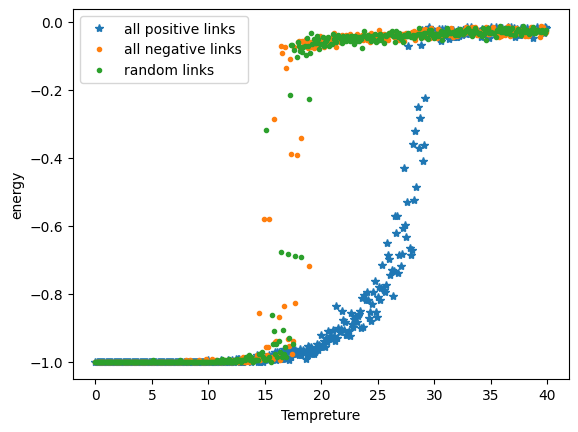

In [114]:
plt.plot(Temp,pos_energy,'*', label = 'all positive links' )
plt.plot(Temp,neg_energy,'.', label = 'all negative links' )
plt.plot(Temp,rand_energy,'.', label = 'random links' )
plt.ylabel('energy')
plt.xlabel('Tempreture')
plt.legend()
plt.show()
# plt.plot(Temp,Mean1, '.',label = 'all negative links')
# plt.plot(Temp,Mean2, '.',label = 'all positive links')
# plt.plot(Temp,Mean3, '.',label = 'random links')
# plt.ylabel('Mean of two stars')
# plt.xlabel('Tempreture')
# plt.legend()
# plt.show()

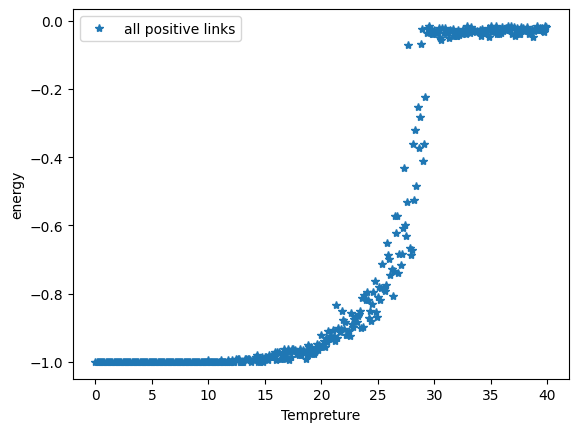

In [115]:
plt.plot(Temp,pos_energy,'*', label = 'all positive links' )
plt.ylabel('energy')
plt.xlabel('Tempreture')
plt.legend()
plt.show()